In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = "Day14_Food_Delivery_Visualization_Dataset.csv"
df = pd.read_csv(DATA_PATH)

df.columns = (
    df.columns.str.strip()
      .str.lower()
      .str.replace(r"[^a-z0-9]+", "_", regex=True)
      .str.strip("_")
)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (360, 16)


,order_batch_id,date,month,day,city,cuisine,order_channel,weather,orders,average_order_value,revenue,marketing_spend,discounts,avg_delivery_minutes,customer_rating,repeat_customer_percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9



Columns:
['order_batch_id', 'date', 'month', 'day', 'city', 'cuisine', 'order_channel', 'weather', 'orders', 'average_order_value', 'revenue', 'marketing_spend', 'discounts', 'avg_delivery_minutes', 'customer_rating', 'repeat_customer_percent']


In [2]:
display(df.info())
display(df.describe(include="all").T)

missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0].to_frame("missing_values"))

# Convert likely date fields when present.
date_candidates = [c for c in df.columns if "date" in c]
for c in date_candidates:
    df[c] = pd.to_datetime(df[c], errors="coerce")

print("Prepared shape:", df.shape)


<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   order_batch_id           360 non-null    str    
 1   date                     360 non-null    str    
 2   month                    360 non-null    str    
 3   day                      360 non-null    str    
 4   city                     360 non-null    str    
 5   cuisine                  360 non-null    str    
 6   order_channel            360 non-null    str    
 7   weather                  360 non-null    str    
 8   orders                   360 non-null    int64  
 9   average_order_value      360 non-null    float64
 10  revenue                  360 non-null    float64
 11  marketing_spend          360 non-null    float64
 12  discounts                360 non-null    float64
 13  avg_delivery_minutes     360 non-null    float64
 14  customer_rating          360 non-null

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_batch_id,360,360,FD0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,360,222,2025-04-26,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,360,12,June,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,360,7,Saturday,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,360,8,Bengaluru,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cuisine,360,6,Healthy,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_channel,360,3,App,211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,360,4,Clear,146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
orders,360.0,NaN,NaN,NaN,147.647222,33.387161,58.0,123.75,147.0,169.0,235.0
average_order_value,360.0,NaN,NaN,NaN,409.151083,70.249186,243.76,353.84,412.41,464.945,575.94


,missing_values


Prepared shape: (360, 16)


In [3]:
date_col = 'date'
orders_col = 'orders'
revenue_col = 'revenue'
city_col = 'city'
cuisine_col = 'cuisine'
marketing_col = 'marketing_spend'
delivery_col = 'avg_delivery_minutes'
rating_col = 'customer_rating'
weather_col = 'weather'
channel_col = 'order_channel'

key_columns = {
    "Date": date_col, "Orders": orders_col, "Revenue": revenue_col,
    "City": city_col, "Cuisine": cuisine_col, "Marketing Spend": marketing_col,
    "Delivery Time": delivery_col, "Customer Rating": rating_col,
    "Weather": weather_col, "Order Channel": channel_col
}
display(pd.DataFrame(key_columns.items(), columns=["Metric", "Detected Column"]))


,Metric,Detected Column
0,Date,date
1,Orders,orders
2,Revenue,revenue
3,City,city
4,Cuisine,cuisine
5,Marketing Spend,marketing_spend
6,Delivery Time,avg_delivery_minutes
7,Customer Rating,customer_rating
8,Weather,weather
9,Order Channel,order_channel


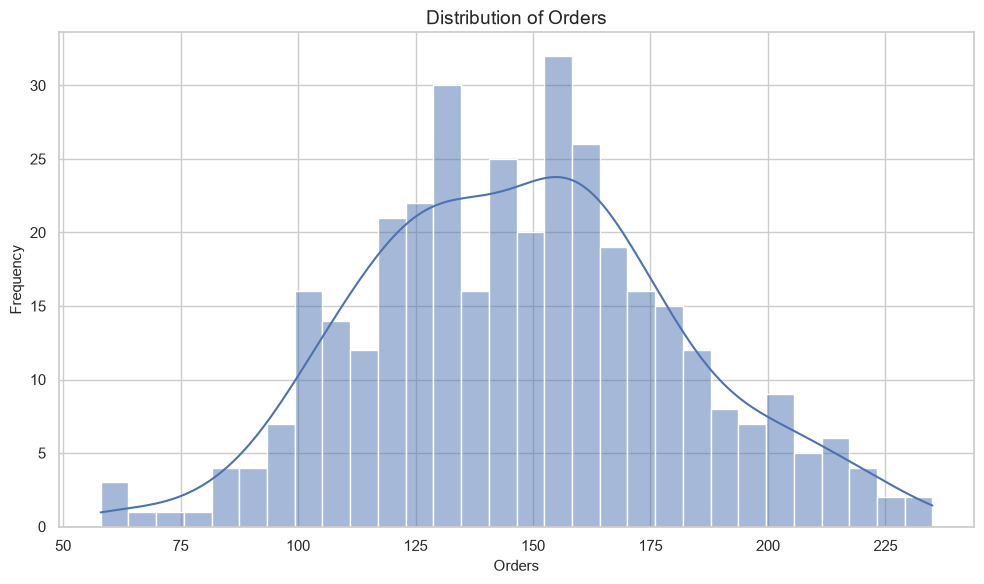

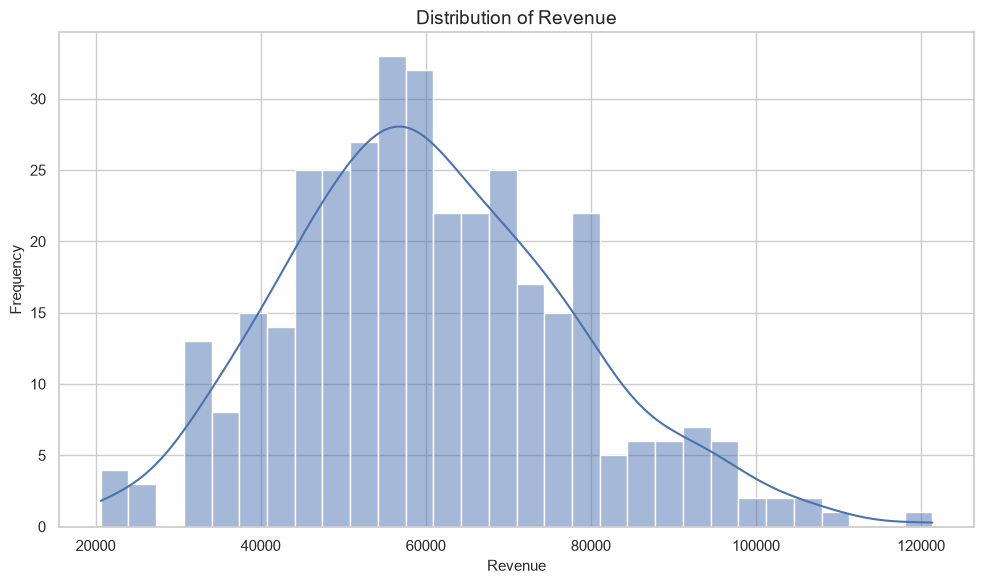

In [4]:
numeric_for_distribution = [c for c in [orders_col, revenue_col] if c is not None and pd.api.types.is_numeric_dtype(df[c])]
if numeric_for_distribution:
    for col in numeric_for_distribution:
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df, x=col, kde=True, bins=30)
        plt.title(f"Distribution of {col.replace('_', ' ').title()}")
        plt.xlabel(col.replace("_", " ").title())
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()
else:
    print("No suitable numeric orders/revenue columns were detected.")


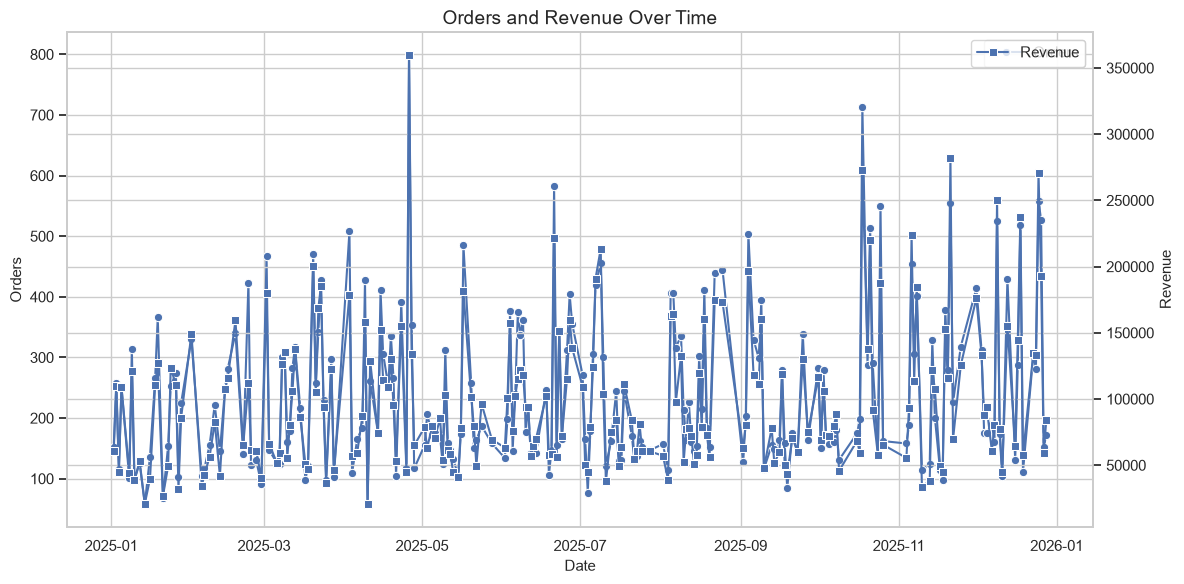

In [5]:
if date_col and orders_col and revenue_col:
    temp = df[[date_col, orders_col, revenue_col]].dropna().sort_values(date_col)
    daily = temp.groupby(date_col, as_index=False)[[orders_col, revenue_col]].sum()

    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.lineplot(data=daily, x=date_col, y=orders_col, marker="o", ax=ax1, label="Orders")
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Orders")

    ax2 = ax1.twinx()
    sns.lineplot(data=daily, x=date_col, y=revenue_col, marker="s", ax=ax2, label="Revenue")
    ax2.set_ylabel("Revenue")

    ax1.set_title("Orders and Revenue Over Time")
    fig.tight_layout()
    plt.show()
else:
    print("Date, orders, or revenue column not detected.")


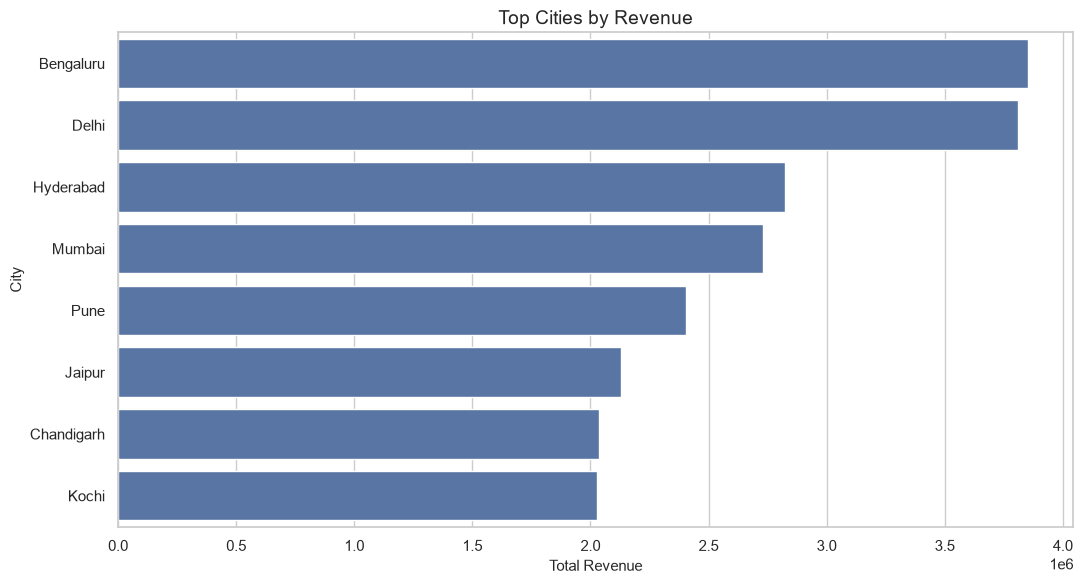

In [6]:
if city_col and revenue_col:
    city_perf = (df.groupby(city_col)[revenue_col]
                   .sum()
                   .sort_values(ascending=False)
                   .head(10)
                   .reset_index())

    plt.figure(figsize=(11, 6))
    sns.barplot(data=city_perf, x=revenue_col, y=city_col)
    plt.title("Top Cities by Revenue")
    plt.xlabel("Total Revenue")
    plt.ylabel("City")
    plt.tight_layout()
    plt.show()
else:
    print("City or revenue column not detected.")


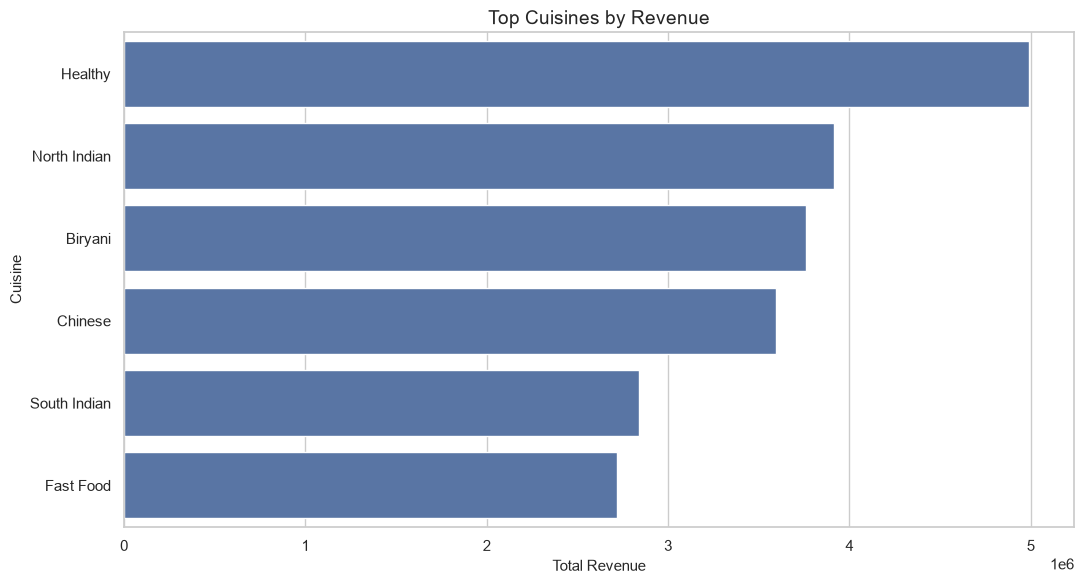

In [7]:
if cuisine_col and revenue_col:
    cuisine_perf = (df.groupby(cuisine_col)[revenue_col]
                      .sum()
                      .sort_values(ascending=False)
                      .head(10)
                      .reset_index())

    plt.figure(figsize=(11, 6))
    sns.barplot(data=cuisine_perf, x=revenue_col, y=cuisine_col)
    plt.title("Top Cuisines by Revenue")
    plt.xlabel("Total Revenue")
    plt.ylabel("Cuisine")
    plt.tight_layout()
    plt.show()
else:
    print("Cuisine or revenue column not detected.")


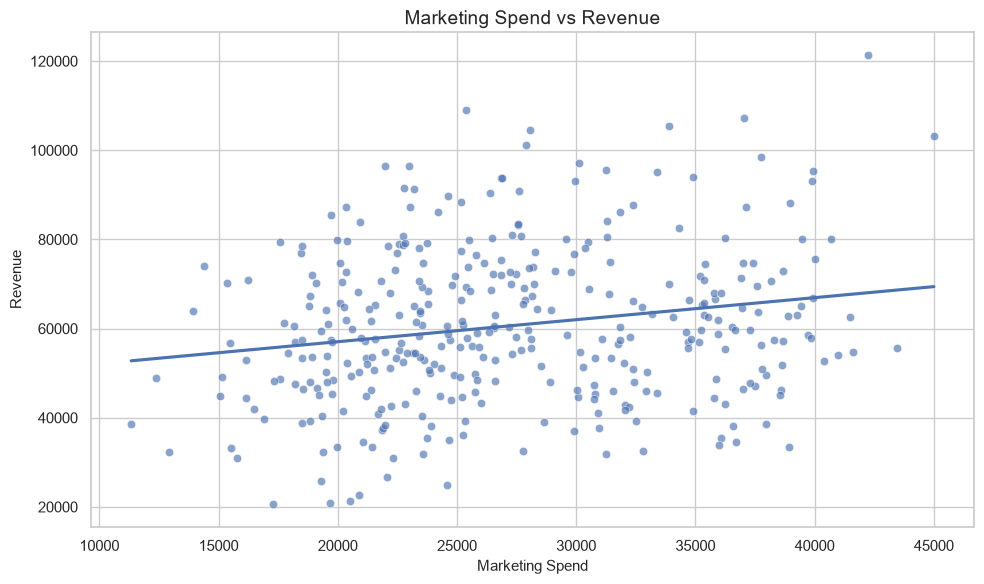

Pearson correlation: 0.19812719039135182


In [8]:
if marketing_col and revenue_col:
    plot_df = df[[marketing_col, revenue_col]].dropna()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_df, x=marketing_col, y=revenue_col, alpha=0.65)
    sns.regplot(data=plot_df, x=marketing_col, y=revenue_col, scatter=False, ci=None)
    plt.title("Marketing Spend vs Revenue")
    plt.xlabel("Marketing Spend")
    plt.ylabel("Revenue")
    plt.tight_layout()
    plt.show()

    print("Pearson correlation:", plot_df[marketing_col].corr(plot_df[revenue_col]))
else:
    print("Marketing spend or revenue column not detected.")


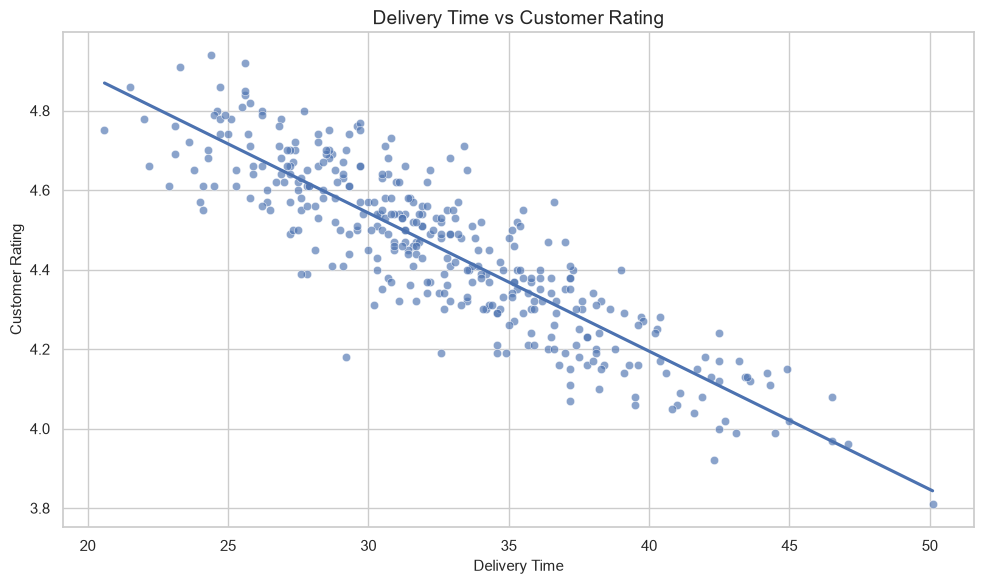

Pearson correlation: -0.8758810555011177


In [9]:
if delivery_col and rating_col:
    plot_df = df[[delivery_col, rating_col]].dropna()

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=plot_df, x=delivery_col, y=rating_col, alpha=0.65)
    sns.regplot(data=plot_df, x=delivery_col, y=rating_col, scatter=False, ci=None)
    plt.title("Delivery Time vs Customer Rating")
    plt.xlabel("Delivery Time")
    plt.ylabel("Customer Rating")
    plt.tight_layout()
    plt.show()

    print("Pearson correlation:", plot_df[delivery_col].corr(plot_df[rating_col]))
else:
    print("Delivery time or customer rating column not detected.")


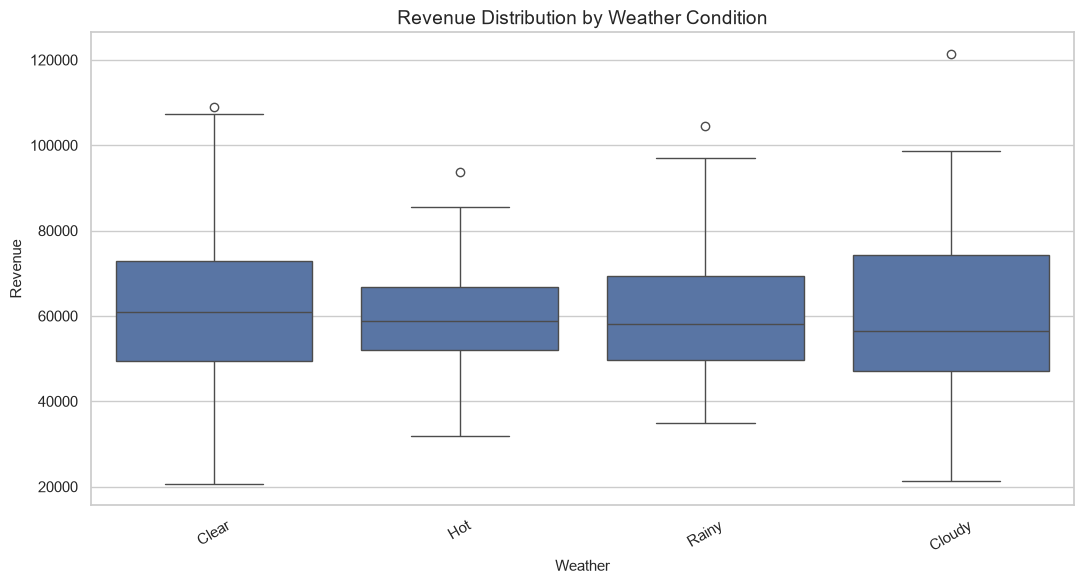

In [11]:
if weather_col and revenue_col:
    plt.figure(figsize=(11, 6))
    order = df.groupby(weather_col)[revenue_col].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=weather_col, y=revenue_col, order=order)
    plt.title("Revenue Distribution by Weather Condition")
    plt.xlabel("Weather")
    plt.ylabel("Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Weather or revenue column not detected.")


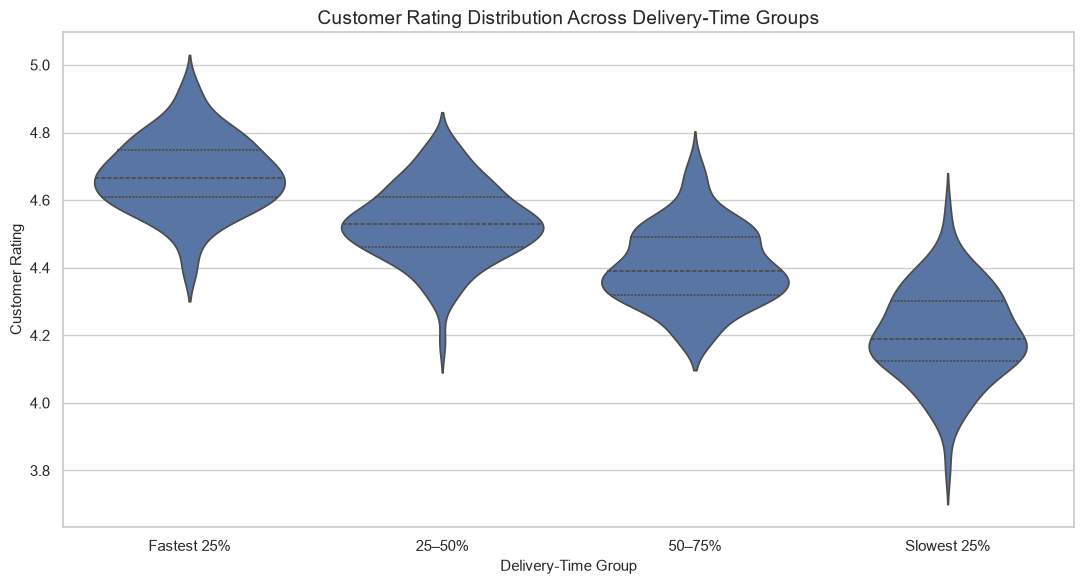

In [12]:
if delivery_col and rating_col:
    temp = df[[delivery_col, rating_col]].dropna().copy()
    # Create interpretable delivery-time groups using quantiles.
    if temp[delivery_col].nunique() >= 4:
        temp["delivery_group"] = pd.qcut(
            temp[delivery_col], q=4,
            labels=["Fastest 25%", "25–50%", "50–75%", "Slowest 25%"],
            duplicates="drop"
        )
        plt.figure(figsize=(11, 6))
        sns.violinplot(data=temp, x="delivery_group", y=rating_col, inner="quartile")
        plt.title("Customer Rating Distribution Across Delivery-Time Groups")
        plt.xlabel("Delivery-Time Group")
        plt.ylabel("Customer Rating")
        plt.tight_layout()
        plt.show()
else:
    print("Delivery time or rating column not detected.")


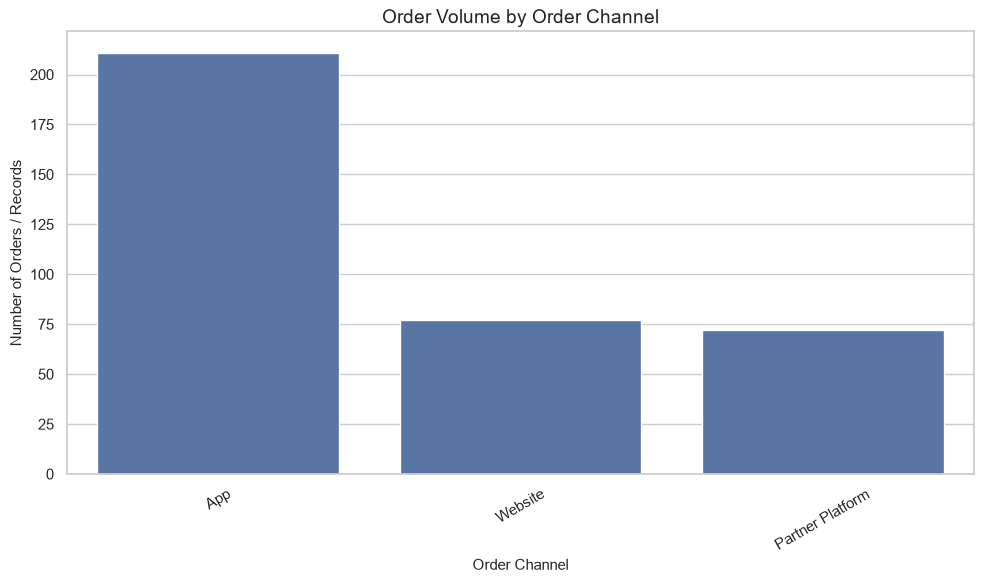

In [13]:
if channel_col:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=channel_col, order=df[channel_col].value_counts().index)
    plt.title("Order Volume by Order Channel")
    plt.xlabel("Order Channel")
    plt.ylabel("Number of Orders / Records")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Order channel column not detected.")


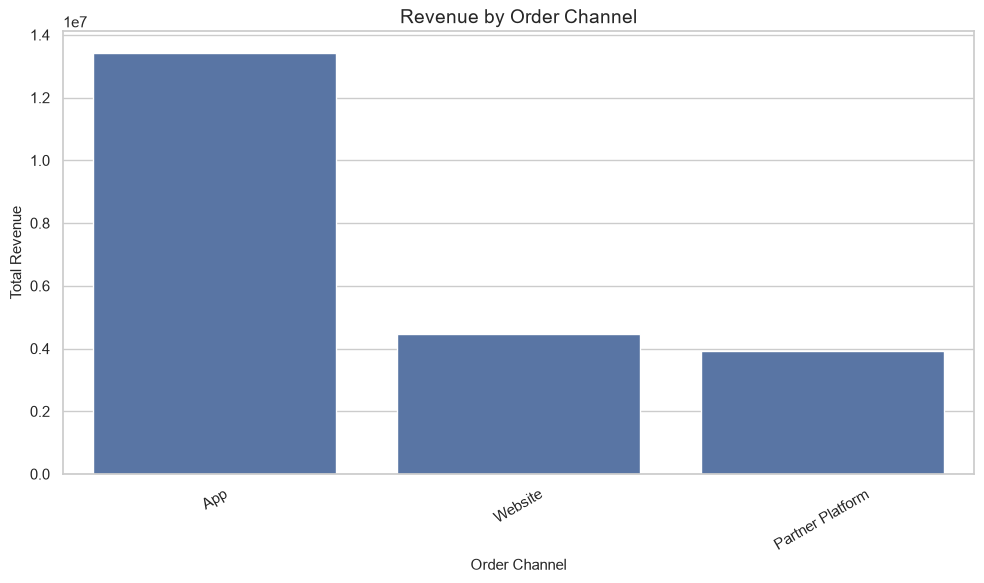

In [14]:
if channel_col and revenue_col:
    channel_rev = (df.groupby(channel_col)[revenue_col]
                     .sum()
                     .sort_values(ascending=False)
                     .reset_index())

    plt.figure(figsize=(10, 6))
    sns.barplot(data=channel_rev, x=channel_col, y=revenue_col)
    plt.title("Revenue by Order Channel")
    plt.xlabel("Order Channel")
    plt.ylabel("Total Revenue")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("Order channel or revenue column not detected.")


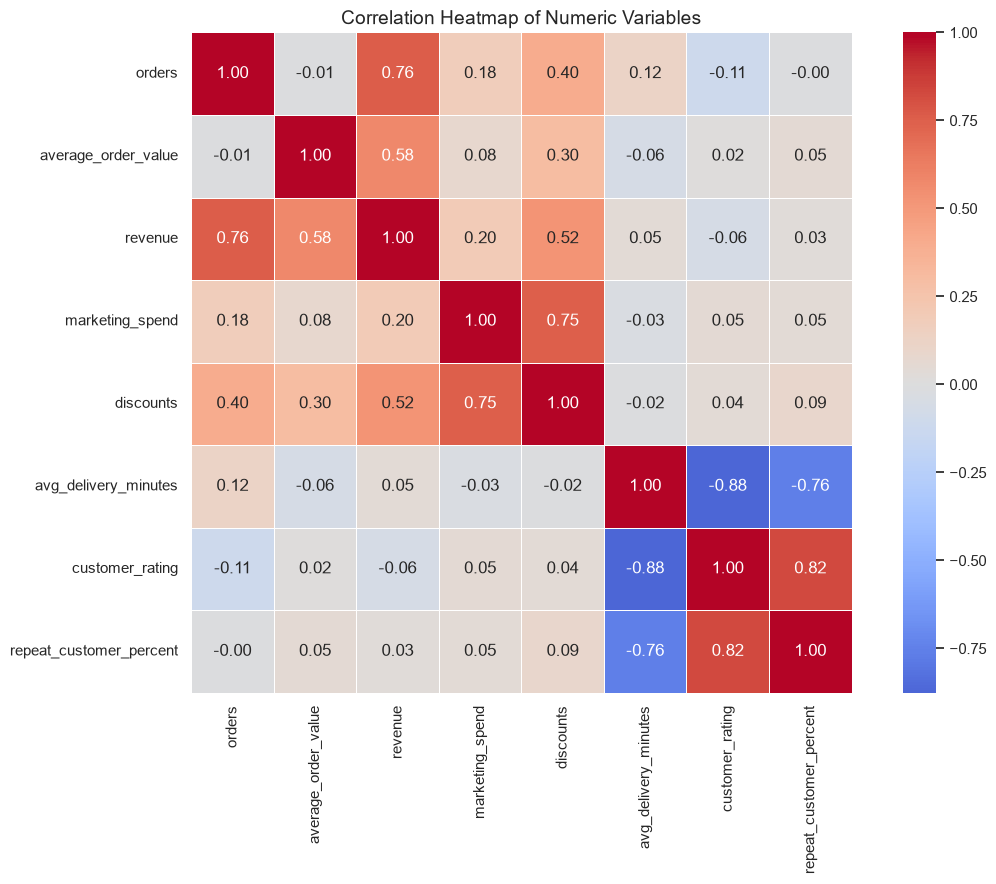

In [15]:
numeric_df = df.select_dtypes(include=np.number)

if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr(numeric_only=True)

    plt.figure(figsize=(12, 9))
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5
    )
    plt.title("Correlation Heatmap of Numeric Variables")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numeric columns are required for a correlation heatmap.")
